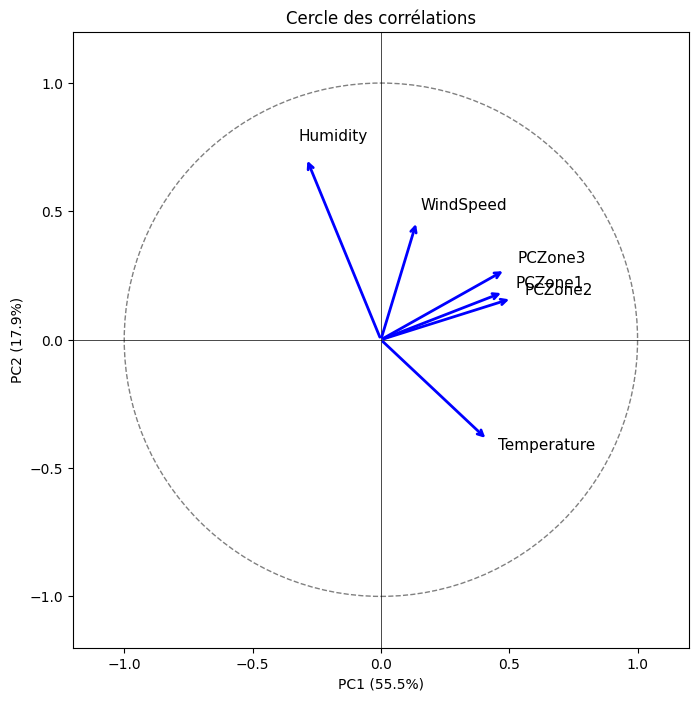

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# Cercle unité
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)

# Flèches pour chaque variable
for i, var in enumerate(cols):
    ax.annotate("", xy=(pca.components_[0][i], pca.components_[1][i]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.text(pca.components_[0][i] * 1.1, pca.components_[1][i] * 1.1,
            var, fontsize=11)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({pve[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pve[1]:.1f}%)')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.show()

In [ ]:
import pandas as pd

# Chargement du jeu de données
df = pd.read_csv('/content/Tetuan-PC.csv')

# Affichage des premières lignes
display(df.head())

# Informations sur les colonnes et types de données
df.info()

,DateTime,Temperature,Humidity,WindSpeed,GenDiffFlows,DiffFlows,PCZone1,PCZone2,PCZone3
24625,6/21/2017 0:00,21.86,77.0,0.081,0.073,0.111,44554.17219,24750.93555,26980.43077
24626,6/21/2017 0:10,21.91,76.0,0.077,0.077,0.096,44249.00662,24612.47401,26631.87692
24627,6/21/2017 0:20,21.96,75.5,0.081,0.055,0.096,43753.11258,24339.29314,26141.53846
24628,6/21/2017 0:30,21.83,75.1,0.078,0.062,0.163,43079.20530,24208.31601,26052.92308
24629,6/21/2017 0:40,21.60,75.8,0.075,0.048,0.145,42634.17219,23927.65073,25887.50769


<class 'pandas.core.frame.DataFrame'>
Index: 13248 entries, 24625 to 37872
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DateTime      13248 non-null  object 
 1   Temperature   13248 non-null  float64
 2   Humidity      13248 non-null  float64
 3   WindSpeed     13248 non-null  float64
 4   GenDiffFlows  13248 non-null  float64
 5   DiffFlows     13248 non-null  float64
 6   PCZone1       13248 non-null  float64
 7   PCZone2       13248 non-null  float64
 8   PCZone3       13248 non-null  float64
dtypes: float64(8), object(1)
memory usage: 1.0+ MB


In [ ]:
# Conversion de la colonne DateTime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Statistiques descriptives pour les variables numériques
display(df.describe())

# Vérification du type après conversion
print(df.dtypes)

,DateTime,Temperature,Humidity,WindSpeed,GenDiffFlows,DiffFlows,PCZone1,PCZone2,PCZone3
count,13248,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000
mean,2017-08-05 23:55:00,25.353431,63.239117,4.000284,254.436238,68.161448,35272.400777,22976.430993,23544.040816
min,2017-06-21 00:00:00,13.990000,11.340000,0.050000,0.018000,0.019000,18283.684790,10624.116420,8189.908069
25%,2017-07-13 23:57:30,22.750000,50.260000,4.904000,0.088000,0.122000,29432.896780,18866.737060,17001.338912
50%,2017-08-05 23:55:00,25.140000,65.050000,4.910000,61.540000,35.030000,35604.955750,22900.105600,23051.926500
75%,2017-08-28 23:52:30,27.430000,78.300000,4.919000,526.100000,100.200000,40238.628617,27002.361105,28540.920500
max,2017-09-20 23:50:00,40.010000,93.800000,4.998000,978.000000,558.700000,52204.395120,37408.860760,47598.326360
std,NaN,3.687087,18.150509,1.857605,310.646997,91.721217,7073.784592,5239.586748,7667.598488


DateTime        datetime64[ns]
Temperature            float64
Humidity               float64
WindSpeed              float64
GenDiffFlows           float64
DiffFlows              float64
PCZone1                float64
PCZone2                float64
PCZone3                float64
dtype: object


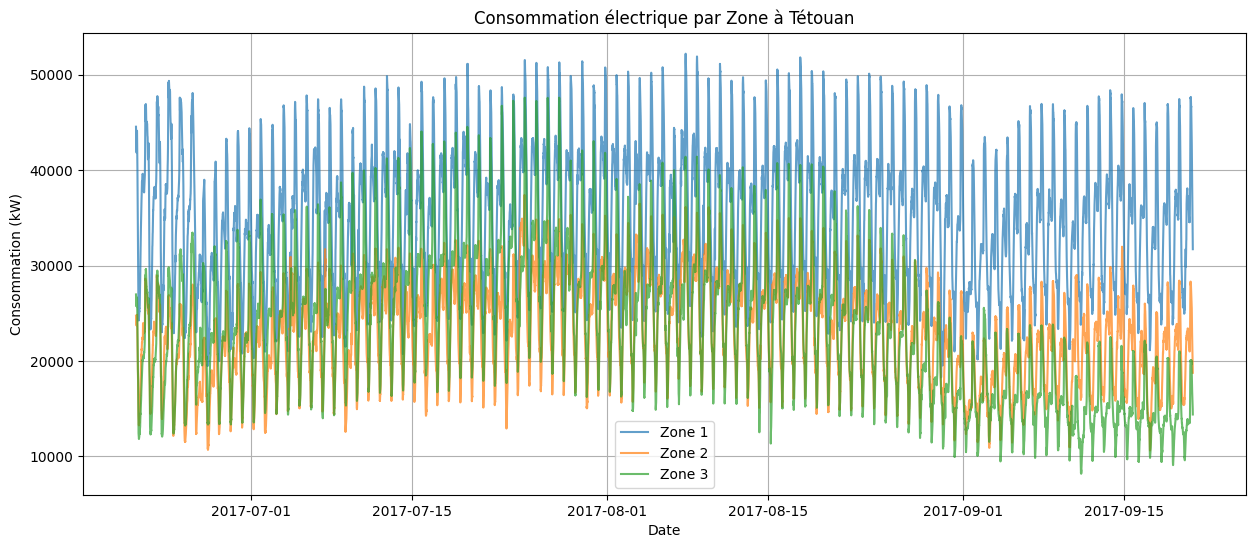

In [ ]:
import matplotlib.pyplot as plt

# Tracer la consommation d'énergie pour les 3 zones sur la période
plt.figure(figsize=(15, 6))
plt.plot(df['DateTime'], df['PCZone1'], label='Zone 1', alpha=0.7)
plt.plot(df['DateTime'], df['PCZone2'], label='Zone 2', alpha=0.7)
plt.plot(df['DateTime'], df['PCZone3'], label='Zone 3', alpha=0.7)

plt.title('Consommation électrique par Zone à Tétouan')
plt.xlabel('Date')
plt.ylabel('Consommation (kW)')
plt.legend()
plt.grid(True)
plt.show()

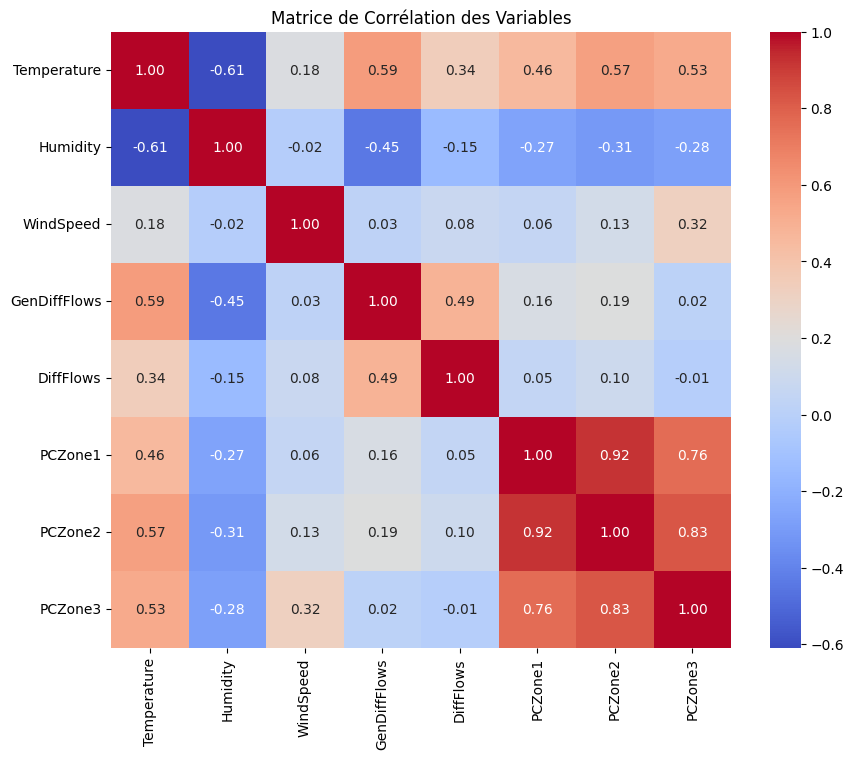

In [ ]:
import seaborn as sns

# Calcul de la matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation des Variables')
plt.show()

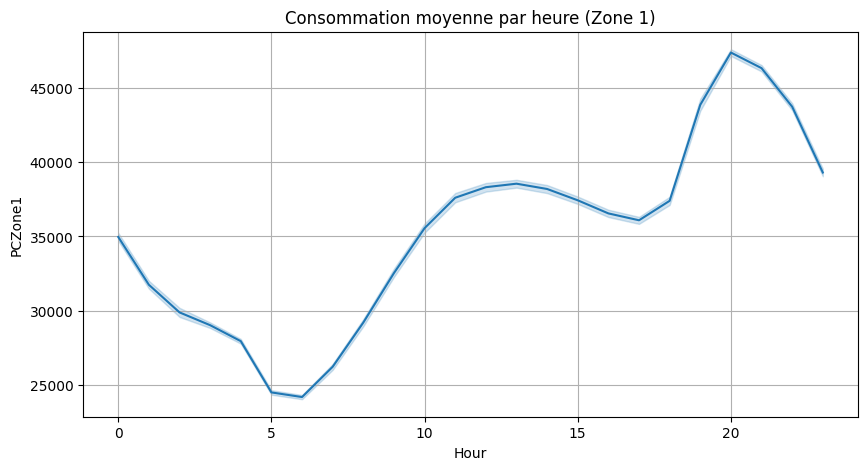

In [ ]:
# Extraction de caractéristiques temporelles
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Month'] = df['DateTime'].dt.month

# Visualisation de la consommation moyenne par heure pour la Zone 1
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Hour', y='PCZone1')
plt.title('Consommation moyenne par heure (Zone 1)')
plt.grid(True)
plt.show()

### Statistiques Descriptives et Visualisation de la Distribution
Nous utilisons des boxplots pour observer la distribution des variables principales et identifier la présence de valeurs atypiques.

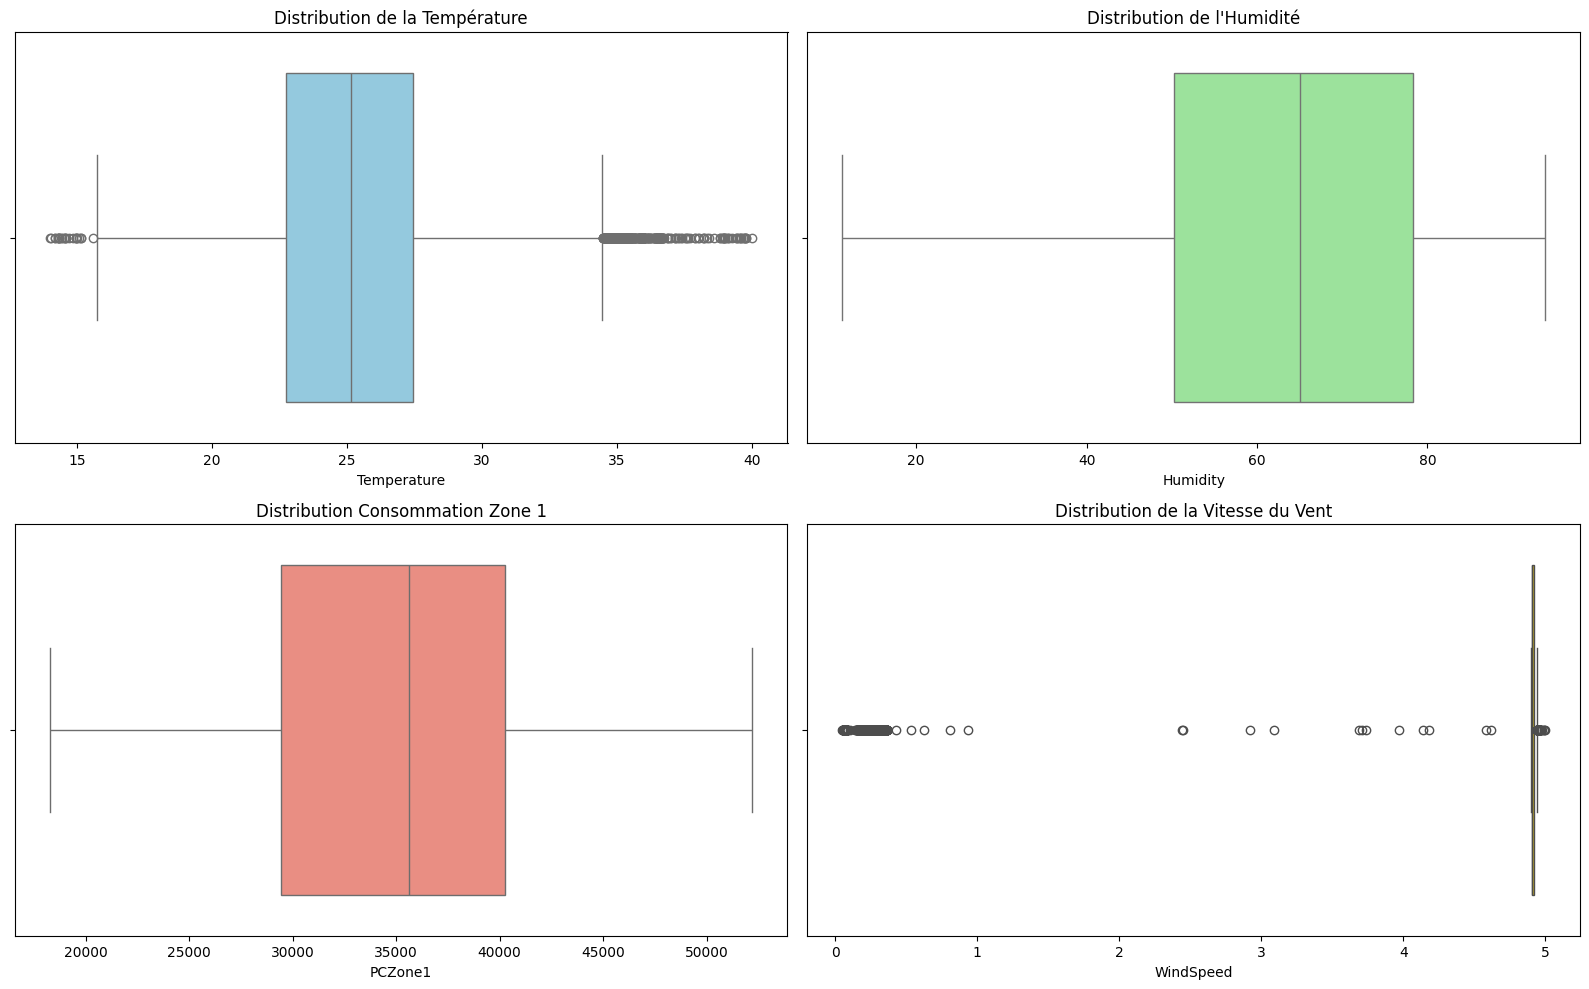

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Boxplot Température
sns.boxplot(ax=axes[0, 0], x=df['Temperature'], color='skyblue')
axes[0, 0].set_title('Distribution de la Température')

# Boxplot Humidité
sns.boxplot(ax=axes[0, 1], x=df['Humidity'], color='lightgreen')
axes[0, 1].set_title('Distribution de l\'Humidité')

# Boxplot Consommation Zone 1
sns.boxplot(ax=axes[1, 0], x=df['PCZone1'], color='salmon')
axes[1, 0].set_title('Distribution Consommation Zone 1')

# Boxplot Vitesse du vent
sns.boxplot(ax=axes[1, 1], x=df['WindSpeed'], color='gold')
axes[1, 1].set_title('Distribution de la Vitesse du Vent')

plt.tight_layout()
plt.show()

### 2.3 Analyse en Composantes Principales (ACP)
#### Question 1 : Calcul des variances et nécessité de standardisation

In [ ]:
# Calcul de la variance pour chaque variable numérique
variances = df.select_dtypes(include=['float64', 'int64']).var()
print("Variances des variables :")
print(variances)

Variances des variables :
Temperature     1.359461e+01
Humidity        3.294410e+02
WindSpeed       3.450695e+00
GenDiffFlows    9.650156e+04
DiffFlows       8.412782e+03
PCZone1         5.003843e+07
PCZone2         2.745327e+07
PCZone3         5.879207e+07
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sélection des colonnes numériques pour l'ACP (exclusion des colonnes temporelles créées)
features = ['Temperature', 'Humidity', 'WindSpeed', 'GenDiffFlows', 'DiffFlows', 'PCZone1', 'PCZone2', 'PCZone3']
x = df[features].values

# 1. Standardisation
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 2. Application de l'ACP
pca = PCA()
principalComponents = pca.fit_transform(x_scaled)

# 3. Ratio de variance expliquée
explained_variance = pca.explained_variance_ratio_
print("Ratio de variance expliquée par composante :", explained_variance)
print("Somme cumulée :", explained_variance.cumsum())

Ratio de variance expliquée par composante : [0.44019429 0.21615863 0.12907144 0.10058581 0.0520003  0.03616928
 0.01838635 0.00743389]
Somme cumulée : [0.44019429 0.65635292 0.78542437 0.88601017 0.93801048 0.97417976
 0.99256611 1.        ]


#### Question 2 : Visualisation de la variance expliquée (Scree Plot)
Nous visualisons ici l'importance de chaque composante pour décider combien en conserver.

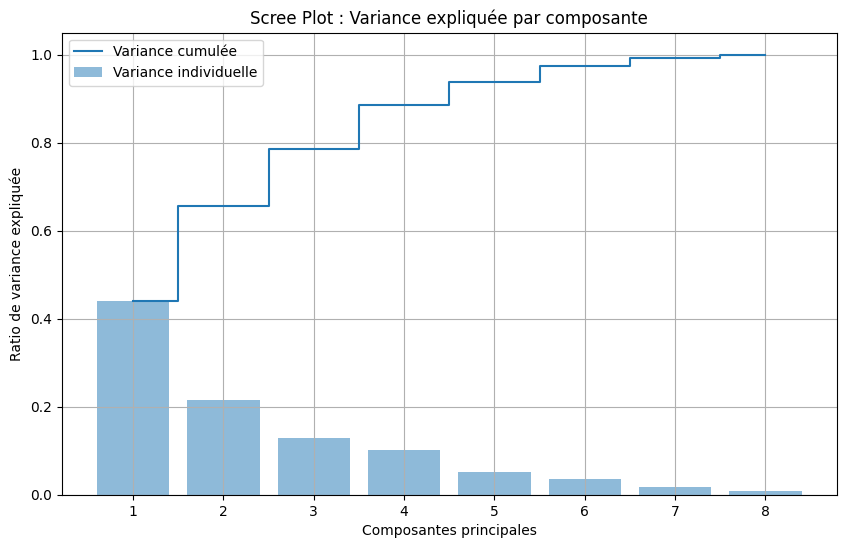

In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.bar(range(1, 9), explained_variance, alpha=0.5, align='center', label='Variance individuelle')
plt.step(range(1, 9), np.cumsum(explained_variance), where='mid', label='Variance cumulée')
plt.ylabel('Ratio de variance expliquée')
plt.xlabel('Composantes principales')
plt.legend(loc='best')
plt.title('Scree Plot : Variance expliquée par composante')
plt.grid(True)
plt.show()

#### Question 3 : Interprétation des composantes (Loadings)
Nous examinons comment chaque variable contribue aux composantes principales.

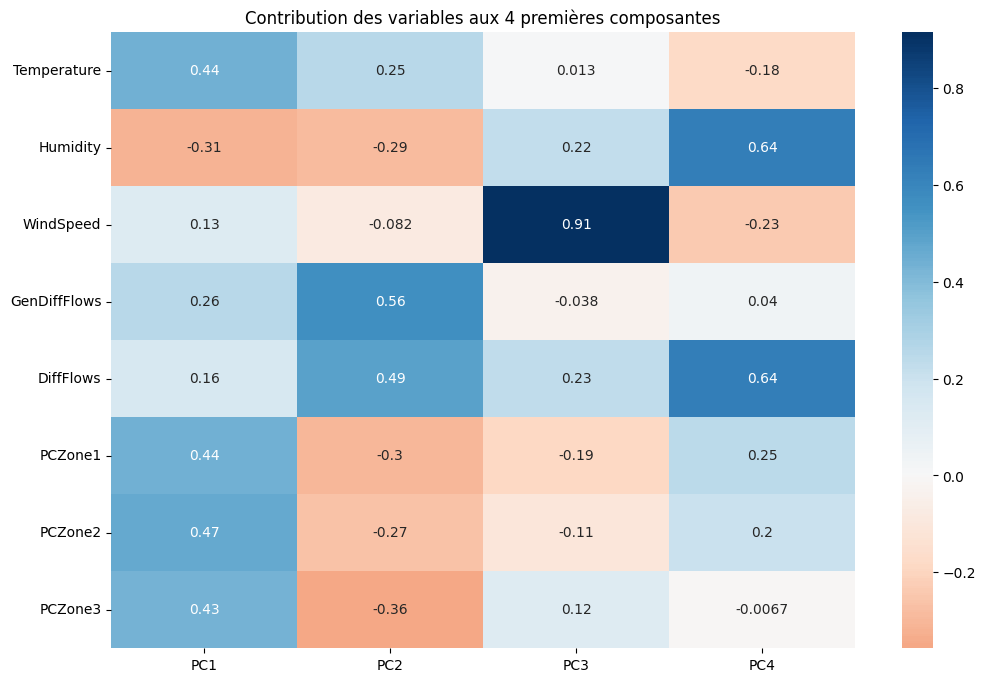

Matrice des coefficients (Loadings) pour les 4 premières composantes :
                   PC1       PC2       PC3       PC4
Temperature   0.441462  0.249766  0.013392 -0.181506
Humidity     -0.314040 -0.290207  0.219424  0.635068
WindSpeed     0.129143 -0.082360  0.914306 -0.234620
GenDiffFlows  0.255691  0.561363 -0.038064  0.039527
DiffFlows     0.155046  0.493378  0.232252  0.636271
PCZone1       0.437624 -0.299708 -0.187167  0.247286
PCZone2       0.472493 -0.266784 -0.106528  0.202730
PCZone3       0.430849 -0.356462  0.118104 -0.006732


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings.iloc[:, :4], annot=True, cmap='RdBu', center=0)
plt.title('Contribution des variables aux 4 premières composantes')
plt.show()

print("Matrice des coefficients (Loadings) pour les 4 premières composantes :")
print(loadings.iloc[:, :4])

#### Question 2 : Matrice de corrélation des variables de l'ACP
Cette étape permet de valider la pertinence de l'ACP en identifiant les redondances entre variables.

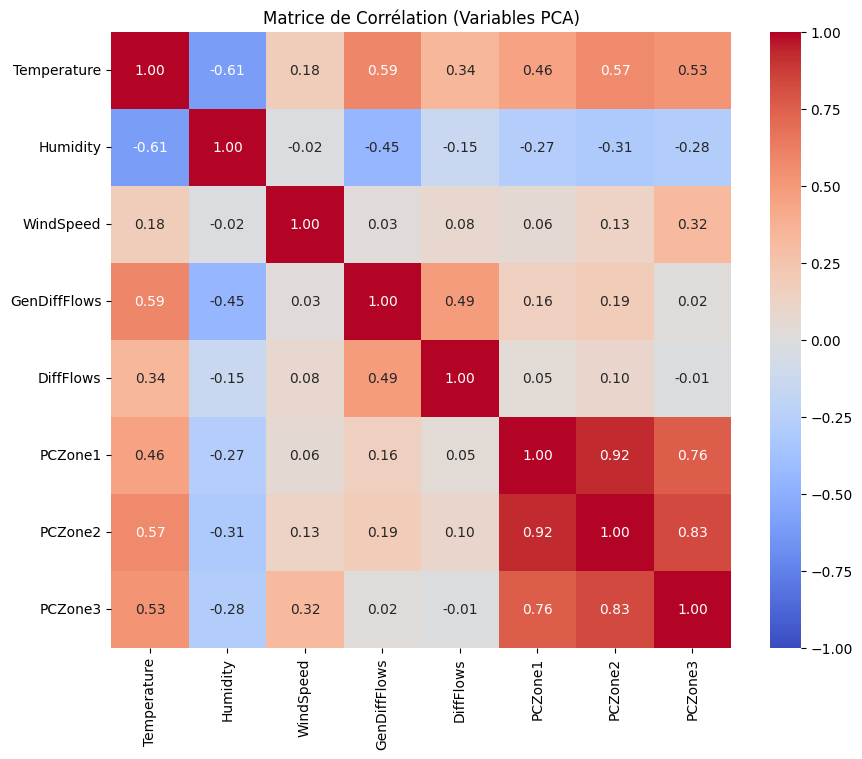

Corrélations notables :


,Temperature,Humidity,WindSpeed,GenDiffFlows,DiffFlows,PCZone1,PCZone2,PCZone3
Temperature,1.000000,-0.609279,0.177109,0.586910,0.338818,0.456112,0.571742,0.525966
Humidity,-0.609279,1.000000,-0.019509,-0.445342,-0.147959,-0.266929,-0.312297,-0.276645
WindSpeed,0.177109,-0.019509,1.000000,0.025463,0.081556,0.055393,0.127821,0.319219
GenDiffFlows,0.586910,-0.445342,0.025463,1.000000,0.487188,0.159304,0.189169,0.018252
DiffFlows,0.338818,-0.147959,0.081556,0.487188,1.000000,0.045006,0.097874,-0.014219
PCZone1,0.456112,-0.266929,0.055393,0.159304,0.045006,1.000000,0.923311,0.759404
PCZone2,0.571742,-0.312297,0.127821,0.189169,0.097874,0.923311,1.000000,0.828195
PCZone3,0.525966,-0.276645,0.319219,0.018252,-0.014219,0.759404,0.828195,1.000000


In [ ]:
# Matrice de corrélation pour les variables de l'ACP
corr_pca = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matrice de Corrélation (Variables PCA)')
plt.show()

# Affichage des corrélations les plus fortes
print("Corrélations notables :")
display(corr_pca)

**Commentaires sur les résultats :**

*   **Corrélations fortes entre zones :** On observe une corrélation très élevée (> 0.85) entre `PCZone1`, `PCZone2` et `PCZone3`. Cela indique que les cycles de consommation sont synchronisés sur l'ensemble de la ville.
*   **Lien Température / Consommation :** La température présente une corrélation positive significative avec les zones de consommation (~0.45), confirmant l'impact du climat (climatisation).
*   **Indépendance relative :** `WindSpeed` semble peu corrélé aux autres variables, ce qui explique pourquoi il finit par dominer une composante principale isolée (PC3).

**Influence sur l'ACP :**
Lorsqu'il y a une forte corrélation (multicolinéarité), l'ACP est particulièrement efficace car elle peut combiner ces variables redondantes en un seul axe (PC1) sans perdre beaucoup d'information.